**Table of contents**<a id='toc0_'></a>    
- [Dipole orientation factor: inidividual average](#toc1_)    
  - [Rotation](#toc1_1_)    
  - [Static](#toc1_2_)    
  - [Distribution of individual average $<\kappa^2>$](#toc1_3_)    
- [Dipole orientation factor for average efficiencies](#toc2_)    
- [Dipole orientation factor for individual transition rate calculations](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Dipole orientation factor: inidividual average](#toc0_)

The dipole orientation factor $\kappa^2$ depends on the angle between the excitation dipole moment of the acceptor and the emission dipole moment of the donor. As they rotate, the average factor of that donor can be calculated as $<\kappa^2>= \frac{1}{t}\int_0^t \kappa^2(t) dt$ where t is the duration of the donor state. If the rotational speed is fast compared to t, all configurations will be visited and $<\kappa^2>$ becomes 2/3. Of course, the average of many donors will also be 2/3. If the rotational speed is slow (approx. static), $<\kappa^2>$ will take values according to the distribution of $\kappa^2$, however the mean will still be 2/3. The mean will not be 2/3 if the configuration space is restricted. Hence, the higher the rotational speed, the closer the **individual** donor state's $<\kappa^2>$ is to 2/3. Generally, the duration of the donor state t depends on the rates of energy transfer, which depends on the time evolution of $\kappa^2$. $\kappa^2(t)$ itself depends on t, hence there is a circular dependency. \
Note that even though the donor has to be in a certain orientation compared to the incident light (electronic field), this constraint does not introduce any differences to the distribution of $\kappa^2$ as $\kappa^2$ measures the relationship of donor to acceptor, and the acceptor is still fully random.

In [1]:
import numpy as np

import fluopy.figure as fi
import fluopy.kappa_squared as kap_sq

%load_ext autoreload
%autoreload 2

## <a id='toc1_1_'></a>[Rotation](#toc0_)

In [5]:
tau_rot = 5e-10
tau_life = 1e-9
dt = 1e-12
traj1, traj2 = kap_sq.simulate_rotational_motion(tau_rot, tau_life, dt, seed=2)
integral = kap_sq.integral_kappa_squared(traj1, traj2, dt)
integral

np.float64(0.09727708569650259)

## <a id='toc1_2_'></a>[Static](#toc0_)

In [2]:
rng = np.random.default_rng(2)
N = 100000
d = kap_sq.random_unit_vector(N, seed=rng)
a = kap_sq.random_unit_vector(N, seed=rng)
r = kap_sq.random_unit_vector(N, seed=rng)
k2_values = kap_sq.kappa_squared(d, a, r)

## <a id='toc1_3_'></a>[Distribution of individual average $<\kappa^2>$](#toc0_)

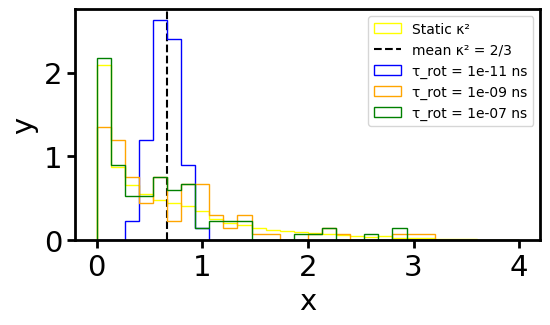

In [10]:
rng = np.random.default_rng(2)
bins = np.linspace(0, 4, 31)
ax = fi.universal_figure(
    type_="hist",
    data=k2_values,
    bins=bins,
    density=True,
    color="yellow",
    histtype="step",
    label="Static κ²",
)
ax[0, 0].axvline(2 / 3, label="mean κ² = 2/3", color="black", linestyle="--")
rot_cor_times = [1e-11, 1e-9, 1e-7]
tau_life = 1e-9
colors = ["blue", "orange", "green"]

for i, rot_cor_time in enumerate(rot_cor_times):
    integrals = []
    for _ in range(100):
        traj1, traj2 = kap_sq.simulate_rotational_motion(
            rot_cor_time, tau_life, dt, seed=rng
        )
        integral = kap_sq.integral_kappa_squared(traj1, traj2, dt)
        integrals.append(integral)
    fi.universal_figure(
        type_="hist",
        data=integrals,
        bins=bins,
        density=True,
        axes=ax[0, 0],
        color=colors[i],
        histtype="step",
        label=f"τ_rot = {rot_cor_time} ns",
        legend=True,
    )

# <a id='toc2_'></a>[Dipole orientation factor for average efficiencies](#toc0_)
In the literature, there is sometimes the value $\kappa^2$ = 0.476 if the regime is static. However, this $\kappa^2$ describes something else than what we talked about above. It emerges from measurements of average FRET efficiencies $<E>$, which is unequal to $E(<\kappa^2>)$ in the static regime. Hence, to get $<E>$ directly, we need to use $\kappa^2$ = 0.476. In the case of highly dynamic regime (i.e., rotational correlation time much smaller than natural lifetime and $\frac{1}{k_{FRET}}$) $<E>$ = $E(<\kappa^2>)$.

# <a id='toc3_'></a>[Dipole orientation factor for individual transition rate calculations](#toc0_)
$k_{FRET}(t) = \alpha * \kappa^2(t)$\
Probability of survival up to time t:\
$1-CDF = S(t) = e^{-\int_0^t (\alpha * \kappa^2(u) + k_{S1}) du}$\
if rotational correlation time is small enough:\
$\int_0^t \kappa^2(u) du = t*<\kappa^2>$\
and $S(t) = e^{-t * (\alpha * <\kappa^2> + k_{S1})}$\
if rotational correlation time is large enough:\
$k_{FRET}(t) = \alpha * \kappa^2$, i.e., $\kappa^2$ is not dependent on time (but on current configuration)\
and $S(t) = e^{-t * (\alpha * \kappa^2 + k_{S1})}$\
if rotational correlation time is intermediate: cyclic dependency of $\kappa^2(\tau)$ and $\tau$\
stepwise checking whether the current $k_{FRET}(t) = \alpha * \kappa^2(t)$ produces an event within stepsize dt:\
Compute $P = 1 - e^{-dt * (k_{FRET}(t) + k_{S1})}$, draw u ~ Uniform(0,1), if u < P, event occurs at $t+dt$, decide which channel fired; if no event set $t += dt$, repeat with new $\kappa^2(t)$\
This is essentially a non-homogenous Poisson point process (NHPP) and could alternatively be modelled with the thinning algorithm.

The relationship of survival function $S(t)$ and hazard function $k(t)$ (which is the event rate at time t, conditional on survival at time t) is generally $S(t) = e^{-\int_0^t f(u)du}$, see survival analysis.\


Intuition for high rotational speeds: Even if a high $\kappa^2$ is reached, it is occupied only for a short period of time and hence still has a low chance to lead to the transition